# Model coastlines for a paleo run

`.x.plot()` picks a plot type from the data's dimensions: a map for anything with
lat/lon, `ncol`, or `nlat`/`nlon`; a filled contour section for other 2-D data; a
line for 1-D.

This is a Miocene simulation, so modern coastlines are simply wrong. The trick is to
pass a **sea-surface variable** as `ssv`: `x4c` contours where that field turns to
NaN, which is exactly the model's own land-sea boundary.

`ssv` has to be on a regular lat/lon grid, so regrid it first.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
ts_path = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.TS.000101-000512.nc',
)
ds = x4c.open_dataset(ts_path, comp='atm', grid='ne16np4', vn='TS', shift_time=True)

ssh_path = os.path.join(
    case_dir, 'ocn', 'proc', 'tseries', 'month_1',
    f'{casename}.pop.h.SSH.000101-000512.nc',
)
ds_ssh = x4c.open_dataset(ssh_path, comp='ocn', grid='g16', vn='SSH', shift_time=True)
ssv = ds_ssh.x.regrid().x.da.mean('time')
da = ds.x.da.x.annualize().mean('time')
print('ssv:', dict(ssv.sizes))

ssv: {'lat': 180, 'lon': 360}


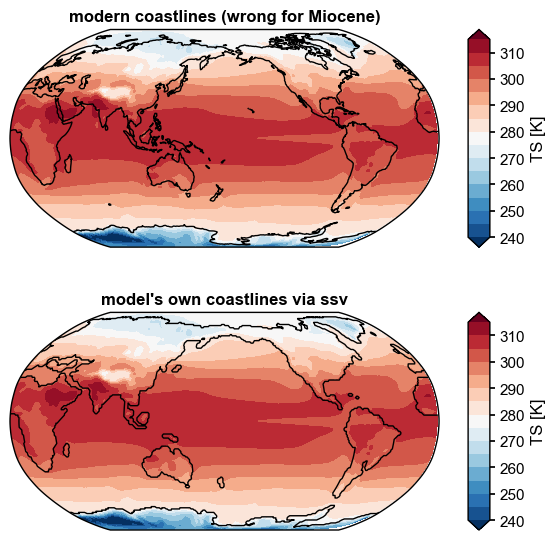

In [3]:
ax_loc = {'a': (0, 0), 'b': (1, 0)}
projs = {k: 'Robinson' for k in ax_loc}
projs_kws = {k: {'central_longitude': 180} for k in ax_loc}
fig, axd = x4c.subplots(2, 1, ax_loc=ax_loc, projs=projs, projs_kws=projs_kws,
                        figsize=(7.5, 6.5), hspace=0.3)

levels = np.linspace(240, 315, 16)
da.x.plot(ax=axd['a'], levels=levels, title='modern coastlines (wrong for Miocene)')
da.x.plot(ax=axd['b'], levels=levels, ssv=ssv, title="model's own coastlines via ssv")
x4c.showfig(fig)